# Myanmar Syllable Normalization Demo (with Version 0.6) 

syl_normalizer.py က ကျွန်တော်တို့ Lab ထဲမှာ သုံးနေတာကြာပါပြီ။ Rule တွေက monolingual corpus, parallel corpus တွေထဲက မြန်မာစာဒေတာထဲမှာ ပါနေတဲ့ အမှားတွေကို အခြေခံပြီး ဆွဲထုတ်ထားတာပါ။ အမှားအများစုကို ပြင်ပေးနိုင်ပါလိမ့်မယ်။ ထပ်တွေ့တဲ့အမှားတွေကိုလည်း ထပ်ဖြည့်ရင်း ပိုကောင်းတဲ့ normalizer ဖြစ်အောင် develop လုပ်နေဆဲပါ။ အဲဒါကို AI Fundamental Class ကျောင်းသားတွေကို statistical machine translation သင်ကြားတဲ့အခါမှာ data cleaning ဥပမာ တစ်ခုအနေနဲ့ သုံးပြခဲ့တာပါ။ သူတို့ကိုလည်း assignment လုပ်ခိုင်းဖို့လိုအပ်တာကော ပြီးတော့ အားလုံးလည်း အသုံးပြုလို့ ရအောင် syllable normalizer version 0.6 အနေနဲ့  release လုပ်ပေးလိုက်ပါတယ်။ မြန်မာစာ NLP/ML/AI ပရောဂျက်တွေအတွက် အသုံးဝင်ပါလိမ့်မယ်။    

ရဲကျော်သူ  
Lab Leader,  
Language Understanding Lab., Myanmar  
Date: 7 May 2026

## Usage Demo  

မြန်မာစာ အမှားတချို့ ပါတဲ့ ဖိုင်တစ်ဖိုင်နဲ့ လက်တွေ normalization လုပ်တာကို ဒီမို လုပ်ပြသွားပါမယ်။   

In [1]:
%cd /home/ye/exp/syl_normalizer/syl_normalizer_v0.6

/home/ye/exp/syl_normalizer/syl_normalizer_v0.6


In [2]:
!python ./syl_normalizer.py --help

usage: syl_normalizer.py [-h] [--input INPUT] [--output OUTPUT] [--log LOG]
                         [--error-output ERROR_OUTPUT] [--verbose]
                         --dictionary DICTIONARY [--frequency N]
                         [--check {dictionary,RE_and_dictionary}]
                         [--fuzzy-distance N] [--ngram-lm ARPA_FILE]
                         [--min-lm-improve DELTA] [--debug-fuzzy]

Burmese Syllable Normalizer v0.6 — Normalizes Myanmar text using rules, n-gram LM fuzzy correction, consonant+asat merging, and compound splitting.

options:
  -h, --help            show this help message and exit
  --input INPUT, -i INPUT
                        Input file (space-separated syllables). Reads from
                        stdin if omitted.
  --output OUTPUT, -o OUTPUT
                        Output file with corrected text. Prints to stdout if
                        omitted.
  --log LOG, -l LOG     File to write detailed per-correction log (every rule
                

## Syllable Dictionary 

Normalizer အတွက်က အနည်းဆုံး syllable dictionary ကို ပြင်ထားဖို့လိုအပ်ပါတယ်။ အဲဒီ dictionary ကိုလည်း ကျွန်တော် ပြင်ဆင်ပေးထားပါတယ်။ Format နဲ့ filesize information က အောက်ပါအတိုင်းပါ။  

In [3]:
!ls -lh ./final_syl_dictionary_13Feb2024.sorted.txt

-rw-rw-r-- 1 ye ye 87K May  7 19:44 ./final_syl_dictionary_13Feb2024.sorted.txt


In [4]:
!wc ./final_syl_dictionary_13Feb2024.sorted.txt

 4999  9998 88814 ./final_syl_dictionary_13Feb2024.sorted.txt


In [5]:
!head -n 30 ./final_syl_dictionary_13Feb2024.sorted.txt

အ 446537
မ 265404
က 232480
ပါ 227422
ကို 217684
တယ် 162388
နေ 143353
ရ 138252
သည် 136534
တာ 126241
သ 106354
မှာ 104510
တွေ 100995
သူ 88344
များ 82267
ဖြစ် 79252
ရှိ 75161
တော့ 75032
ရာ 73757
တဲ့ 71221
လေး 68036
ပြီး 66962
တစ် 66774
ကြ 64774
နိုင် 64192
တော် 63840
နဲ့ 63731
လာ 63060
တို့ 61127
ပေး 60909


In [6]:
!tail -n 30 ./final_syl_dictionary_13Feb2024.sorted.txt

အိန့် 2
အိမ္ဗာ 2
အိုက်စ့် 2
အိုက်စ်စ်စ်စ် 2
အိုင်စ် 2
အိုစ် 2
အိုလ် 2
အီစ္စာ 2
အီးစ် 2
အီလ် 2
အူလ္လာ 2
အဲန်း 2
အဲမ် 2
အဲ့လ်ပ်စ် 2
ဣတ် 2
ဣန္တာ 2
ဣန္ဒေ 2
ဥဏ္ဏ 2
ဥဏ် 2
ဥဒ္ဒိ 2
ဥပ္ပဇ္ဇေ 2
ဥမ္မတ္တ 2
ဥရ် 2
ဥုတ္တ 2
ဥ္စင်း 2
ဦးရ် 2
ဧတ္တ 2
ဧတ္တာ 2
ဩတ္တ 2
ဩောင်း 2


ဒီ syllable အဘိဓာန်က ကျွန်တော်တို့ ပြင်ပကို release မလုပ်ရသေးတဲ့ monolingual corpus စာကြောင်းရေ တစ်သန်းခွဲခန့် ကနေ ဆွဲထုတ်ထားတာပါ။ ဒိုမိန်းကတော့ general domain ပါ။ အဲဒါကြောင့် လက်တွေ့ မြန်မာတွေကရိုက်ထားတဲ့ စာကြောင်းတွေထဲကနေပဲ ဆွဲထုတ်ယူထားတာပါ။ တချို့ အမှားတွေလည်း ပါပါလိမ့်မယ်။ သို့သော် တတ်နိုင်သမျှ cleaning လုပ်ထားပြီး အနည်းဆုံး frequency နှစ်ကြိမ်ပါတဲ့ syllable (ဝဏ္ဏ သို့မဟုတ် ဝဏ္ဏနဲ့တူသော) တွေကို စုဆောင်းထားတာဖြစ်ပါတယ်။  

## Stage-1

တော်တော်များများ NLP Task တွေအတွက်က stage-1 နဲ့ပဲ အဆင်ပြေပါလိမ့်မယ်။ Stage-1 ကပဲ အန္တရာယ်အကင်းဆုံးလို့ ယူဆပါတယ်။  
test.my က ကျွန်တော် ထိုင်းဘက်က Lab မှာ ပြင်ဆင်နေကြတဲ့ parallel corpus တွေထဲက အမှား အကြောင်း တစ်ရာကို ဆွဲထုတ် ယူထားတာပါ။ ဒိုမိန်းက medical domain နဲ့ ပတ်သက်တဲ့ စာကြောင်းတွေပါ။  

In [8]:
!ls -lh test.my

-rw-rw-r-- 1 ye ye 15K May  7 20:01 test.my


In [10]:
!cat test.my

အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် 
အ ချို ကို လျေ့ာ ချ ကြ ည့် လိုက် ပါ
လွန် ခဲ့ တဲ့ နှစ် က ကို ယ့် ဌာ န မန် နေ ဂျာ က ကိုယ် အ မှား လုပ် ခဲ့ တာ တွေ အ တွက် အ ပြစ် စ တင် ထဲ က ပါ 
ခွဲ ထား တာ ကို ဂ ရု စိုက် လို့ ရ အောင် ဆ ရာ ဝန် က ကပ် ပေး လိ မ့် မယ်
မှတ် ပုံ တင် ပြ လို့ ရ မ လား ရှ င့်
သူ မ မှာ ဒဏ် ရာ မ ရှိ ဘူး  ဒါ ပေ မ ယ့် သူ က ဟို နား ဒီ နား နာ ကျင် နေ တယ် ပြော နေ တယ် 
ကို ယ့် က လေး အ တော် မော ပန်း နေ တယ် 
နား လေး ခြင်း  အို မင်း ရ င့် ရော် ခြင်း 
အဲ့ အ ရင် တုန်း က ကိုက် တယ် ဆို တာ ဘယ် လောက် ကြာ ပြီ လဲ ရှ င့်
သ င့် ရဲ့ အိမ် ခေါ် နာ မည် အ ပြင် အ ခြား နာ မည် ရော ဘယ် လို ပေး ထား ပါ သ လဲ 
သ င့် ရဲ့ ဖုန်း နာ ပါတ် ကို ပြော ပြ ပေး လို့ ရ မ လား 
အ စာ အိမ် ထဲ ကို ဗိုင်း ရက်စ် ရော ၀င် တာ ဖြစ် ပါ တယ် 
သား အိမ် နံ ရံ တွင် တွဲ ကပ် နေ ရ သော သန္ဓေ သား ၏ ပုံ စံ နှ င့် နေ ရာ
သို့ ပေ မ ယ့် သူ အား နည်း နေ တာ လည်း မ သိ ဘူး ရှ င့်
သိ လိုက် ပါ ပြီ  ဒီ နေ့ အ တွက် တော့ ကျွန် မ ကို ရှ င့် အ ကြောင်း တွေ ပြော ပြ စေ ချင

**Stage-1 နဲ့ပဲ normalization လုပ်ကြည့်ရအောင်။**  

In [12]:
%mkdir stage-1

In [13]:
!time python3 syl_normalizer.py \
      --dictionary ./final_syl_dictionary_13Feb2024.sorted.txt --frequency 2 \
      --input test.my --output stage-1/test.my.clean.txt \
      --log ./stage-1/corrections.log --error-output ./stage-1/errors.txt \
      --fuzzy-distance 0

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :        100
  Tokens processed   :      1,550
  Passthrough        :         31
  Already valid      :      1,403

  Fixed - stage 1 (rules, token count)    :        1
  Fixed - stage 1 (individual rule apps)  :        1

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :      103
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :        104
  Still unknown

In [14]:
!tree ./stage-1/

./stage-1/
├── corrections.log
├── errors.txt
└── test.my.clean.txt

1 directory, 3 files


stage-1/ ဖိုလ်ဒါအောက်မှာ ဖိုင် သုံးဖိုင်ကို output အနေနဲ့ တွေ့ရပါလိမ့်မယ်။  
errors.txt ဆိုတဲ့ ဖိုင်က rules တွေနဲ့ detect လုပ်ပြီးတွေ့တဲ့ အမှားတွေကို ထောင့်ကွင်းတွေနဲ့ ပြထားပေတဲ့ ဖိုင်ပါ။   
အောက်ပါအတိုင်းပါ။  

In [16]:
 !wc ./stage-1/errors.txt

  100  1550 14676 ./stage-1/errors.txt


In [17]:
!head ./stage-1/errors.txt

အ ရက် ကို စွ <န့်> လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ <င့်> ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ <င့်> သည်
အ ချို ကို <လျေ့ာ> ချ ကြ <ည့်> လိုက် ပါ
လွန် ခဲ့ တဲ့ နှစ် က ကို <ယ့်> ဌာ န မန် နေ ဂျာ က ကိုယ် အ မှား လုပ် ခဲ့ တာ တွေ အ တွက် အ ပြစ် စ တင် ထဲ က ပါ
ခွဲ ထား တာ ကို ဂ ရု စိုက် လို့ ရ အောင် ဆ ရာ ဝန် က ကပ် ပေး လိ <မ့်> မယ်
မှတ် ပုံ တင် ပြ လို့ ရ မ လား ရှ <င့်>
သူ မ မှာ ဒဏ် ရာ မ ရှိ ဘူး ဒါ ပေ မ <ယ့်> သူ က ဟို နား ဒီ နား နာ ကျင် နေ တယ် ပြော နေ တယ်
ကို <ယ့်> က လေး အ တော် မော ပန်း နေ တယ်
နား လေး ခြင်း အို မင်း ရ <င့်> ရော် ခြင်း
အဲ့ အ ရင် တုန်း က ကိုက် တယ် ဆို တာ ဘယ် လောက် ကြာ ပြီ လဲ ရှ <င့်>
သ <င့်> ရဲ့ အိမ် ခေါ် နာ မည် အ ပြင် အ ခြား နာ မည် ရော ဘယ် လို ပေး ထား ပါ သ လဲ


In [18]:
!tail ./stage-1/errors.txt

တ ဒင်္ဂ ပုံ မှန် မ ဟုတ် နိုင် တဲ့ အ ချိန် မှာ ထွက် ရှိ လိုင်း တွေ ကြော <င့်> ဖြစ် ပေါ် စေ တတ် တယ်
က လေး စိတ် ထဲ မှာ ရှိ တာ ကို ပြော ခွ <င့်> ပေး ရ မယ်
သွေး အ ဖြေ ကို ခ ဏ လောက် စော <င့်> ပေး ပါ
မ စင် အ တွက် အိတ် ထ <ည့်> ပေး ပါ မယ်
အ ရမ်း ကြီး နာ မှာ လား ဆ ရာ <၀န်>
အ ကယ် လို့ ၉ ၁ ၁ ကို ခေါ ပြီး အ ရေး ပေါ် အ ခန်း ထဲ သွား ရ တယ် ဆို ရင် သ <င့်> မှာ C O V I D - 1 9 ရော ဂါ ကူး စက် ထား တယ် ဆို တာ ကို အ သိ ပေး ပါ ဒါ မှ မ ဟုတ်
နောက် ပြီး ကျွန် တော် ပါ အဲ့ ဒိ ပိုး သတ် ဆေး အ ဆိပ် သ <င့်> ရော ဂါ ဖြစ် နိုင် လား ဗျ
အ ခု ဘယ် နား နာ နေ သေး လဲ ရှ <င့်>
သ <င့်> ရဲ့ မျက် လုံး အ တွင်း ကို ခေါင်း လျှော် ရည် မ ဟုတ် ရင် တ ခု ခု ဝင် သွား လို့ တွေ နာ နေ တာ ကို မှတ် မိ သေး လား
သိပ် မ သေ ချာ ဘူး ရှ <င့်>


*အထက်မှာ မြင်ရတဲ့အတိုင်းပါပဲ။ အမှားအများစုက အသတ်၊ အောက်ကမြစ် မရိုက်ပဲ အောက်ကမြစ် အသတ်အဖြစ် ရိုက်ထားတာ (သို့မဟုတ်) အသုံးပြုခဲ့တဲ့ font converter ကြောင့် ဖြစ်တဲ့ အမှားလို့ ယူဆပါတယ်။ ဒီအမှားတွေက တကယ့် ကောပတ်စ်ထဲက အမှားတွေပါပဲ။*  

corrections.log ဖိုင်ကတော့ အဲဒီ အမှားတွေကို syl_normalizer.py က ဘယ်လို ပြင်ထားသလဲ ဆိုတာကို debug လုပ်လို့ ရအောင် မှတ်သားပေးထားတဲ့ log ဖိုင်ပါ။  

In [19]:
!wc ./stage-1/corrections.log

  104   941 13316 ./stage-1/corrections.log


In [20]:
!head -n 30 ./stage-1/corrections.log

line      1 | 'စွ န့်'                       -> 'စွန့်'                        | stage3:merge_with_previous
line      1 | 'နှ င့်'                       -> 'နှင့်'                        | stage3:merge_with_previous
line      1 | 'သ င့်'                        -> 'သင့်'                         | stage3:merge_with_previous
line      2 | 'ကြ ည့်'                       -> 'ကြည့်'                        | stage3:merge_with_previous
line      3 | 'ကို ယ့်'                      -> 'ကိုယ့်'                       | stage3:merge_with_previous
line      4 | 'လိ မ့်'                       -> 'လိမ့်'                        | stage3:merge_with_previous
line      5 | 'ရှ င့်'                       -> 'ရှင့်'                        | stage3:merge_with_previous
line      6 | 'မ ယ့်'                        -> 'မယ့်'                         | stage3:merge_with_previous
line      7 | 'ကို ယ့်'                      -> 'ကိုယ့်'                       | stage3:merge_with_previous
line      8 | 'ရ င့်'       

test.my.clean.txt ဖိုင်ကတော့ normalization လုပ်ထားပြီးသား ဖိုင်ပါ။ တနည်းအားဖြင့် syllable unit level အမှားတော်တော်များများကို ပြင်ထားပြီးသား ဖိုင်ပါ။   
လေ့လာကြည့်ကြရအောင်။  


In [21]:
 !wc ./stage-1/test.my.clean.txt

  100  1447 14341 ./stage-1/test.my.clean.txt


In [22]:
!head ./stage-1/test.my.clean.txt

အ ရက် ကို စွန့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှင့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သင့် သည်
အ ချို ကို လျေ့ာ ချ ကြည့် လိုက် ပါ
လွန် ခဲ့ တဲ့ နှစ် က ကိုယ့် ဌာ န မန် နေ ဂျာ က ကိုယ် အ မှား လုပ် ခဲ့ တာ တွေ အ တွက် အ ပြစ် စ တင် ထဲ က ပါ
ခွဲ ထား တာ ကို ဂ ရု စိုက် လို့ ရ အောင် ဆ ရာ ဝန် က ကပ် ပေး လိမ့် မယ်
မှတ် ပုံ တင် ပြ လို့ ရ မ လား ရှင့်
သူ မ မှာ ဒဏ် ရာ မ ရှိ ဘူး ဒါ ပေ မယ့် သူ က ဟို နား ဒီ နား နာ ကျင် နေ တယ် ပြော နေ တယ်
ကိုယ့် က လေး အ တော် မော ပန်း နေ တယ်
နား လေး ခြင်း အို မင်း ရင့် ရော် ခြင်း
အဲ့ အ ရင် တုန်း က ကိုက် တယ် ဆို တာ ဘယ် လောက် ကြာ ပြီ လဲ ရှင့်
သင့် ရဲ့ အိမ် ခေါ် နာ မည် အ ပြင် အ ခြား နာ မည် ရော ဘယ် လို ပေး ထား ပါ သ လဲ


**အမှားတွေကို ပြင်ဆင်ထားတာကို မပြင်ခင်ကဖိုင်နဲ့ ယှဉ်ကြည့်ရင် သိနိုင်ပါလိမ့်မယ်။ ဒါမှမဟုတ် အထက်က ပြောခဲ့တဲ့ log ဖိုင်တွေနဲ့ တိုက်ကြည့်ရင်လည်း မြင်နိုင်ပါလိမ့်မယ်။**  

In [23]:
!tail ./stage-1/test.my.clean.txt

တ ဒင်္ဂ ပုံ မှန် မ ဟုတ် နိုင် တဲ့ အ ချိန် မှာ ထွက် ရှိ လိုင်း တွေ ကြောင့် ဖြစ် ပေါ် စေ တတ် တယ်
က လေး စိတ် ထဲ မှာ ရှိ တာ ကို ပြော ခွင့် ပေး ရ မယ်
သွေး အ ဖြေ ကို ခ ဏ လောက် စောင့် ပေး ပါ
မ စင် အ တွက် အိတ် ထည့် ပေး ပါ မယ်
အ ရမ်း ကြီး နာ မှာ လား ဆ ရာ ၀န်
အ ကယ် လို့ ၉ ၁ ၁ ကို ခေါ ပြီး အ ရေး ပေါ် အ ခန်း ထဲ သွား ရ တယ် ဆို ရင် သင့် မှာ C O V I D - 1 9 ရော ဂါ ကူး စက် ထား တယ် ဆို တာ ကို အ သိ ပေး ပါ ဒါ မှ မ ဟုတ်
နောက် ပြီး ကျွန် တော် ပါ အဲ့ ဒိ ပိုး သတ် ဆေး အ ဆိပ် သင့် ရော ဂါ ဖြစ် နိုင် လား ဗျ
အ ခု ဘယ် နား နာ နေ သေး လဲ ရှင့်
သင့် ရဲ့ မျက် လုံး အ တွင်း ကို ခေါင်း လျှော် ရည် မ ဟုတ် ရင် တ ခု ခု ဝင် သွား လို့ တွေ နာ နေ တာ ကို မှတ် မိ သေး လား
သိပ် မ သေ ချာ ဘူး ရှင့်


## Pipeline of Syllable Normalization  

အထက်မှာ လုပ်ပြခဲ့တာက RE rules နဲ့ syllable frequency dictionary ကိုပဲ သုံးပြီး normalization လုပ်ခဲ့တာပါ။ Version 0.6 မှာက ngram dictionary နဲ့ fuzzy သုံးပြီး မှားနေတဲ့ syllable တွေကို ဝင်ပြင်နိုင်အောင်လည်း ရေးထားပါတယ်။ Overview သို့မဟုတ် pipeline က အောက်ပါ ပုံအတိုင်းပါပဲ။   

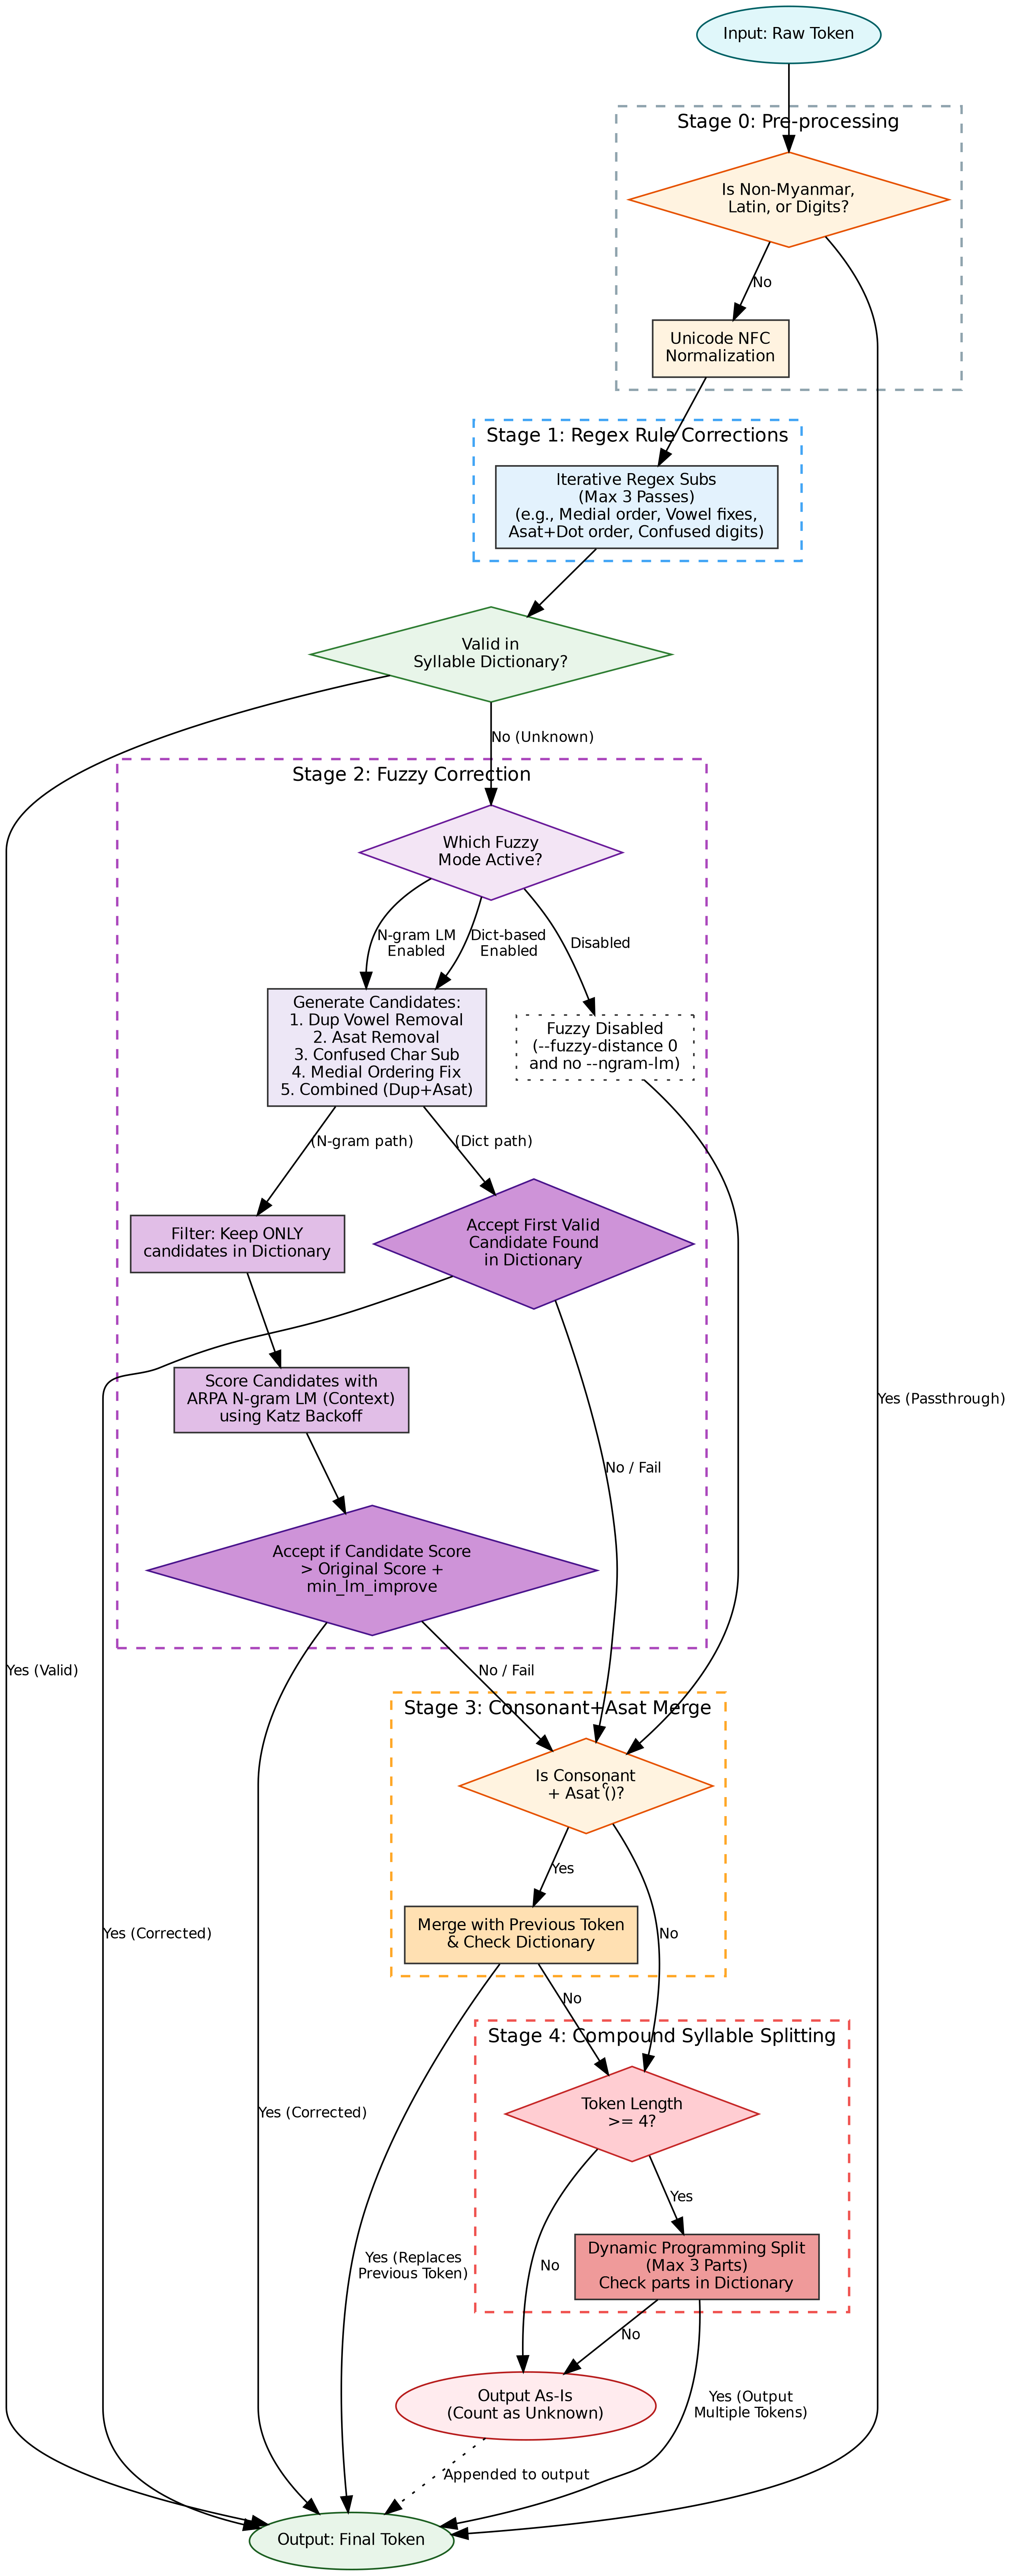

In [2]:
from IPython import display
display.Image("/home/ye/exp/syl_normalizer/syl_normalizer_v0.6/overview/pipeline.png", width=600)

## n-gram LM-guided Fuzzy Correction  

ဒီတစ်ခါတော့ n-gram အဘိဓာန်ကိုပါ သုံးပြီး language model guided fuzzy correction နည်းလမ်းနဲ့ တချို့မှားနေတာတွေကိုပါ ဝင်ပြင်ကြည့်ပါမယ်။ သတိထားစေချင်တာက ဆောက်ထားတဲ့ trigram language model အပေါ်ကိုမူတည်ပြီး ပြင်တာမို့ limitation တွေရှိတယ် ဆိုတဲ့ အချက်ကိုပါ။ တချို့ အမှားတွေကို အမှန်အဖြစ် ပြောင်းပေးနိုင်မှာဖြစ်ပေမဲ့ တပြိုင်နက်တည်း တချို့ မှန်တာတွေကိုလည်း အမှားအဖြစ် ပြောင်းပစ်လိုက်တာမျိုးတွေ ရှိနိုင်တယ် ဆိုတာကို မမေ့ပါနဲ့။ အဲဒါကြောင့် အခြေခံအားဖြင့်က stage-1 ကိုပဲ သုံးပြီး normalization လုပ်ဖြစ်တာများပါတယ်။   

ဒီတခါတော့ မတူတဲ့ test data ကို သုံးပါမယ်။  

In [12]:
%cd /home/ye/exp/syl_normalizer/syl_normalizer_v0.6

/home/ye/exp/syl_normalizer/syl_normalizer_v0.6


In [13]:
!cat -n ./ngram/test2.txt

     1	မြန် မာ သ မိုင်း ကုန် ဘောင် ရာ ဇ ဝင် တွင် လုပ် ရည် ကြံ ရည် ရှိ လျက် ကံ အ ကြောင်း မ လှ သ ဖြ င့် မင်း အ ဖြစ် ကို မ ရ သော မင်း သား များ အ နက် ပြည် မင်း သား နှ င့် က နောင် မင်း သား တို့ မှာ သာ ယာ ဝ တီ မင်း မှ ဖွား တော် မူ သော သား တော် များ အ နက် လက် ရုံး ၇ည် နှ င့် နှ လုံး ရည် ပြ ည့် ဝ သော သား တော် များ ဖြစ် သည် အ ပြင် နန်း တွင် ပ ညာ ရှိ မှူး မတ် ပြည် သူ များ က ချစ် ခင် လေး စား သော မင်း သား ၂ ပါး ဖြစ် သည် ။
     2	မိ ဖု ရား စော သဒ္ဓာ သား တော် နန္ဓ ဘ ရ သ မီး တော် သု ပ ဘာ ဒေ ဝီ ။
     3	ယွာ ဘ က လည်း ၊ မာ ၏ လား ငါ့ ညီ ဟု အာ မ သ ကို မေး ၍ နမ်း ဟန် ဆောင် လျက် လက်ျာ လက် နှင့် အာ မ သ ၏ မုတ် ဆိတ် ကို ကိုင် ၏ ။
     4	မိုး ညှင်း သမ္ဗုဒ္ဒေ စေ တီ ရှေ့ လမ်း မ ပေါ် တွင် ထ နောင်း ပင် ကြီး တစ် ပင် လဲ ကျ ခဲ့ ပြီး လမ်း ပိတ် ဆို့ မှု များ လည်း ဖြစ် ပေါ် ခဲ့ သည် ။
     5	က လေး ကို ဘယ် သူ ပဲ ကောက် ချီ လိုက် ကောက် ချီ လိုက် မွှေး မွှေး ကြိုင် ကြိုင် သန့် သန့် ရျင် ရျင်း လေး ဖြစ် စေ ချင် တယ် ဟုတ် ။
     6	မ အိပ် မှီ တံ ခါး နှင် ပြ တင်း ပေါက် ဂျက် များ ချ ထား ခြင်း ၊ လမ်း ကြောင်း ရှိ ပ ရိ ဘော ဂ ပစ္စည်း မျ

In [14]:
%%bash
time python3 ./syl_normalizer.py \
      --dictionary ./final_syl_dictionary_13Feb2024.sorted.txt --frequency 2 \
      --ngram-lm myMono_syl_trigram.arpa \
      --min-lm-improve 0.5 \
      --input ./ngram/test2.txt \
      --output ./ngram/test2.clean.txt \
      --log ./ngram/corrections.log --error-output ./ngram/errors.txt

  Loading n-gram LM: myMono_syl_trigram.arpa
  LM loaded: 35,298 unigrams, 957,132 bigrams, 6,612,522 trigrams  (unk=-6.011)
  Fuzzy correction: n-gram LM mode  (min_improve=0.50 log10 units)

=== syl_normalizer summary (v0.6) ===
  Lines processed    :         43
  Tokens processed   :      1,939
  Passthrough        :        123
  Already valid      :      1,612

  Fixed - stage 1 (rules, token count)    :        0
  Fixed - stage 1 (individual rule apps)  :        0

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :       15
  Fixed - stage 2 ngram (char sub)        :       30
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :    

အထက်မှာ မြင်ရတဲ့အတိုင်း ngram LM ကိုသုံးပြီး ပြင်သွားတာကို မြင်ရပါလိမ့်မယ်။ input test ဒေတာမှာ ပါတဲ့ အမှားတွေရဲ့ အပေါ်လည်း မူတည်ပါလိမ့်မယ်။ test2.txt အရ ဆိုရင်တော့ အောက်ပါ error နှစ်မျိုးကို ဝင်ပြင်ပေးသွားပါတယ်။  

  Fixed - stage 2 ngram (asat removal)    :       15
  Fixed - stage 2 ngram (char sub)        :       30
  

In [16]:
!ls ./ngram/

corrections.log  errors.txt  preparation  test2.clean.txt  test2.txt  tmp


detect ဖြစ်တဲ့ error တွေကို ဝင်လေ့လာရအောင်။ ပုဒ်ထီး၊ ပုဒ်မ က syllable အဘိဓာန်ထဲမှာ ထည့်မထားလို့ အဲဒါကိုလည်း error အဖြစ် ယူဆတာ ဖြစ်ပေမဲ့ code ထဲမှာ ဝင်မပြင်အောင် ရေးထားပါတယ်။  

In [17]:
!cat ./ngram/errors.txt

မြန် မာ သ မိုင်း ကုန် ဘောင် ရာ ဇ ဝင် တွင် လုပ် ရည် ကြံ ရည် ရှိ လျက် ကံ အ ကြောင်း မ လှ သ ဖြ <င့်> မင်း အ ဖြစ် ကို မ ရ သော မင်း သား များ အ နက် ပြည် မင်း သား နှ <င့်> က နောင် မင်း သား တို့ မှာ သာ ယာ ဝ တီ မင်း မှ ဖွား တော် မူ သော သား တော် များ အ နက် လက် ရုံး <၇ည်> နှ <င့်> နှ လုံး ရည် ပြ <ည့်> ဝ သော သား တော် များ ဖြစ် သည် အ ပြင် နန်း တွင် ပ ညာ ရှိ မှူး မတ် ပြည် သူ များ က ချစ် ခင် လေး စား သော မင်း သား ၂ ပါး ဖြစ် သည် <။>
မိ ဖု ရား စော <သဒ္ဓာ> သား တော် <နန္ဓ> ဘ ရ သ မီး တော် သု ပ ဘာ ဒေ ဝီ <။>
<ယွာ> ဘ က လည်း <၊> မာ ၏ လား ငါ့ ညီ ဟု အာ မ သ ကို မေး ၍ နမ်း ဟန် ဆောင် လျက် လက်ျာ လက် နှင့် အာ မ သ ၏ မုတ် ဆိတ် ကို ကိုင် ၏ <။>
မိုး ညှင်း <သမ္ဗုဒ္ဒေ> စေ တီ ရှေ့ လမ်း မ ပေါ် တွင် ထ နောင်း ပင် ကြီး တစ် ပင် လဲ ကျ ခဲ့ ပြီး လမ်း ပိတ် ဆို့ မှု များ လည်း ဖြစ် ပေါ် ခဲ့ သည် <။>
က လေး ကို ဘယ် သူ ပဲ ကောက် ချီ လိုက် ကောက် ချီ လိုက် မွှေး မွှေး ကြိုင် ကြိုင် သန့် သန့် <ရျင်> <ရျင်း> လေး ဖြစ် စေ ချင် တယ် ဟုတ် <။>
မ အိပ် မှီ တံ ခါး နှင် ပြ တင်း ပေါက် ဂျက် များ ချ ထား ခြင်း <၊> လမ်း ကြောင်း ရှိ ပ ရိ ဘော ဂ ပစ္စည်း များ ကို

**တချို့ အမှားတွေက အမြင်နဲ့ပဲ ကြည့်ရင် နားလည်ရ ခက်ပါလိမ့်မယ်။**  
ဥပမာ "ပစောင်ကနဲ့ ဝိုက်ချ" လိုအတွဲမျိုးဆိုရင် ပုံမှန် ဗျည်း "ဟ" အနေနဲ့ မြင်ရမှာ ဖြစ်ပါတယ်။  

ဘယ်လိုမျိုး ပြင်သွားသလဲ ဆိုတာကို debug လုပ်နိုင်ဖို့အတွက် log ဖိုင်ကို အသေးစိတ် ပြင်ဆင်ပေးထားပါတယ်။ corrections.log မှာ ngram LM ကို သုံးပြီး ပြင်သွားတဲ့ အပိုင်းတွေကိုလည်း စစ်ဆေးလို့ ရပါတယ်။  

In [18]:
!cat ./ngram/corrections.log

line      1 | 'ဖြ င့်'                       -> 'ဖြင့်'                        | stage3:merge_with_previous
line      1 | 'နှ င့်'                       -> 'နှင့်'                        | stage3:merge_with_previous
line      1 | '၇ည်'                          -> 'ရည်'                          | stage2:ngram(ngram_char_sub)
line      1 | 'နှ င့်'                       -> 'နှင့်'                        | stage3:merge_with_previous
line      1 | 'ပြ ည့်'                       -> 'ပြည့်'                        | stage3:merge_with_previous
line      2 | 'နန္ဓ'                         -> 'နန္ဒ'                         | stage2:ngram(ngram_char_sub)
line      3 | 'ယွာ'                          -> 'ရွာ'                          | stage2:ngram(ngram_char_sub)
line      4 | 'သမ္ဗုဒ္ဒေ'                    -> 'သမ္ဗုဒ္ဓေ'                    | stage2:ngram(ngram_char_sub)
line      5 | 'ရျင်'                         -> 'လျင်'                         | stage2:ngram(ngram_char_sub)
line      5 | 'ရျင

**တကယ်တမ်း ပြင်သွားတဲ့ ဝဏ္ဏတိုင်းက မှန်တယ် မမှန်ဘူး ဆိုတာကတော့ context နဲ့ တွဲကြည့်မှပဲ ဆုံးဖြတ်လို့ ရပါလိမ့်မယ်။ လောလောဆယ် တချို့ NLP task တွေအတွက် အသုံးဝင်တာမို့ facility တစ်ခုအနေနဲ့ ဖြည့်ထားတာပါ။ still developing လုပ်နေဆဲပါပဲ။**  

In [19]:
!cat ./ngram/test2.clean.txt

မြန် မာ သ မိုင်း ကုန် ဘောင် ရာ ဇ ဝင် တွင် လုပ် ရည် ကြံ ရည် ရှိ လျက် ကံ အ ကြောင်း မ လှ သ ဖြင့် မင်း အ ဖြစ် ကို မ ရ သော မင်း သား များ အ နက် ပြည် မင်း သား နှင့် က နောင် မင်း သား တို့ မှာ သာ ယာ ဝ တီ မင်း မှ ဖွား တော် မူ သော သား တော် များ အ နက် လက် ရုံး ရည် နှင့် နှ လုံး ရည် ပြည့် ဝ သော သား တော် များ ဖြစ် သည် အ ပြင် နန်း တွင် ပ ညာ ရှိ မှူး မတ် ပြည် သူ များ က ချစ် ခင် လေး စား သော မင်း သား ၂ ပါး ဖြစ် သည် ။
မိ ဖု ရား စော သဒ္ဓာ သား တော် နန္ဒ ဘ ရ သ မီး တော် သု ပ ဘာ ဒေ ဝီ ။
ရွာ ဘ က လည်း ၊ မာ ၏ လား ငါ့ ညီ ဟု အာ မ သ ကို မေး ၍ နမ်း ဟန် ဆောင် လျက် လက်ျာ လက် နှင့် အာ မ သ ၏ မုတ် ဆိတ် ကို ကိုင် ၏ ။
မိုး ညှင်း သမ္ဗုဒ္ဓေ စေ တီ ရှေ့ လမ်း မ ပေါ် တွင် ထ နောင်း ပင် ကြီး တစ် ပင် လဲ ကျ ခဲ့ ပြီး လမ်း ပိတ် ဆို့ မှု များ လည်း ဖြစ် ပေါ် ခဲ့ သည် ။
က လေး ကို ဘယ် သူ ပဲ ကောက် ချီ လိုက် ကောက် ချီ လိုက် မွှေး မွှေး ကြိုင် ကြိုင် သန့် သန့် လျင် လျင်း လေး ဖြစ် စေ ချင် တယ် ဟုတ် ။
မ အိပ် မှီ တံ ခါး နှင် ပြ တင်း ပေါက် ဂျက် များ ချ ထား ခြင်း ၊ လမ်း ကြောင်း ရှိ ပ ရိ ဘော ဂ ပစ္စည်း များ ကို ရှင်း လင်း ထား ခြင်း နှင့် လှေ ကား များ